<a href="https://colab.research.google.com/github/nickplas/Intro_to_ML_24-25/blob/main/notebooks/Lab-10.KernelPCA_KernelSVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as LA

from scipy.spatial.distance import pdist, squareform
from scipy.linalg import eigh


Kernel regression
===============

https://knork.medium.com/linear-regression-in-python-from-scratch-with-kernels-e9c37f7975b9

**Recap**: the solution of the linear regression $y=wX$ can be also written as:

$$
w=(X^{T}X)^{-1}X^{T}y=X^{T}(XX^{T})^{-1}y
$$


Let $X\in R^{N\times d}$, then $X^{T}X\in R^{d\times d}$ and $K=XX^{T}\in R^{N\times N}$: it all depends on the ratio $\frac{d}{N}$ which matrix is more convenient (i.e. less computational demanding) to compute. 

For predictions, we plug the above for a test point $z$ and get:

$$
f(z)=z^{T}w=z^{T} X^{T}(XX^{T})^{-1}y= \alpha^{T}(z)K^{-1}y
$$

with $\alpha(z)=z^{T}X^{T}=K(z,X)\in R^{1\times N}$.

This is the case for linear regression. How can we extend to the non-linear case?  $x\rightarrow \phi(x)$, and the reasoning above repeats.


Also: https://github.com/luigicarratino/Tutorial_Kernels_MLSS2019_London/blob/master/Tutorial%20Kernel.ipynb



## Recap on different kernel functions 

See also: https://www.cs.toronto.edu/~duvenaud/cookbook/

1. **Linear Kernel**: $k(x, y) = <x, y> = x\cdot y$ fast to compute, hence convenient when there are a lot of features and no need to map points in a higher dimensional space. Usually combined with other kernels to increase their expressiveness. 

2. **Polynomial Kernel**: $k(x, y)= (1 + x\cdot y)^p$ ($p$ is the degree) non-linear function if $p>1$, it allows to cnsider interactions among features up to order $p$.

3. **Radial Basis Funtion / Gaussian Kernel**: $k(x, y) = \bigg( -\frac{||x - y||_2}{2 \sigma^2} \bigg)$ it is arguably the most used, as it can map points potentially to infinite dimenional space (think about Taylor expansion) hence it is potentially able to fit any dataset. 

In [2]:
def kernelFunc(x1, x2, kernel_type, param):
    if kernel_type == 'poly':
        return (1 + np.dot(x1, x2)) ** param
    elif kernel_type == 'rbf':
        return np.exp(- np.dot(x1-x2,x1-x2) / (2 * param))
    elif kernel_type == 'linear':
        return np.dot(x1,x2)

RBF Kernel PCA
=============

***PCA recap***

Normalization

$$
x\rightarrow x-\frac{1}{d}\sum_{j}(x)_{j}
$$

Eigenvectors of the covariance matrix are the new coordinates (thanks to normalization):
$$
Cv=\lambda v\;\;\;\;\;\;\;C=\frac{1}{N}\sum_{i}x_{i}x^{T}_{i}
$$

The first $d$ eigenvalues provide information about the amount of information (i.e. variance) retained if we use only the first $d$ eigendirection.

<img src="http://www.nlpca.org/fig_pca_principal_component_analysis.png" alt= “” width="600" height="300">





However it may not be applicable to data at hand:

<img src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/pca_example_1.png" alt= “” width="800" height="400">



***Kernel PCA***

**Intuition**: use a kernel function to map features in a different (often higher dimensional) feature space, then perform dimensionality reduction in this new space using PCA.

New Features
$$
x\rightarrow \phi(x)
$$

Covariance eigenvalues and eigenvectors:

$$
C_{K}v=\lambda v\;\;\;\;\;\;\;\;C_{K}=\frac{1}{N}\sum_{i}\phi(x_{i})\phi^{T}(x_{i})
$$

One can prove that eigenvectors are linear combinations of features: 

$$
v=\sum_{i}\alpha_{i}\phi(x_{i})\;\;\; \alpha_i = \frac{\phi(x_i)^T v}{N\lambda}
$$

This comes from the fact that K should be a *Gram Matrix*, which is symmetric positive definite and we search for
a low rank approximation of the Kernel. The Kernel for how it is computed is not readily a good Gram Matrix, it should undergo a process called
*Double Centering* (this is only a requirement to center the matrix around 0, requiring only a linear transformation on elements). The math behind
is quite verbose, if you want more info ask me.

Multiplying both sides of $C_{K}v=\lambda v$ by $\phi(x_{k})$ we have the following eigendecomposition:

$$
N\lambda \alpha = K \alpha
$$

Normalization
$$
\phi(x)\rightarrow \phi(x)-\frac{1}{d}\sum_{i}(\phi(x))_{i} 
$$

The resulting kernel is

$$
K\rightarrow K - \dfrac{1}{N}\mathbb{1}K - \dfrac{1}{N}K\mathbb{1} + \dfrac{1}{N^2}\mathbb{1}K\mathbb{1}
$$

with $\mathbb{1}$ being the matrix of all ones


See also  https://sdat.ir/en/sdat-blog/python-kernel-tricks-and-nonlinear-dimensionality-reduction-via-rbf-kernel-pca


Performing PCA in a higher dimension might be more suitable:

<img src="https://2.bp.blogspot.com/_slrAR0IXTL0/TF-OZaNbRCI/AAAAAAAAAUo/SdYS3hXd4MI/s1600/figure.png" alt= “” width="600" height="600">

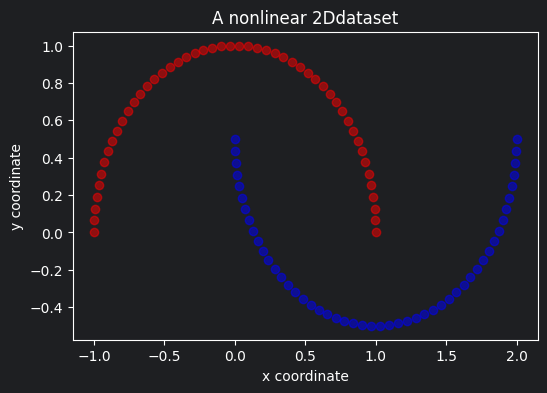

In [3]:
# very famous example of non-linearly-separable dataset
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, random_state=123)

plt.figure(figsize=(6,4))

plt.scatter(X[y==0, 0], X[y==0, 1], color='red', alpha=0.5)
plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', alpha=0.5)

plt.title('A nonlinear 2Ddataset')
plt.ylabel('y coordinate')
plt.xlabel('x coordinate')

plt.show()

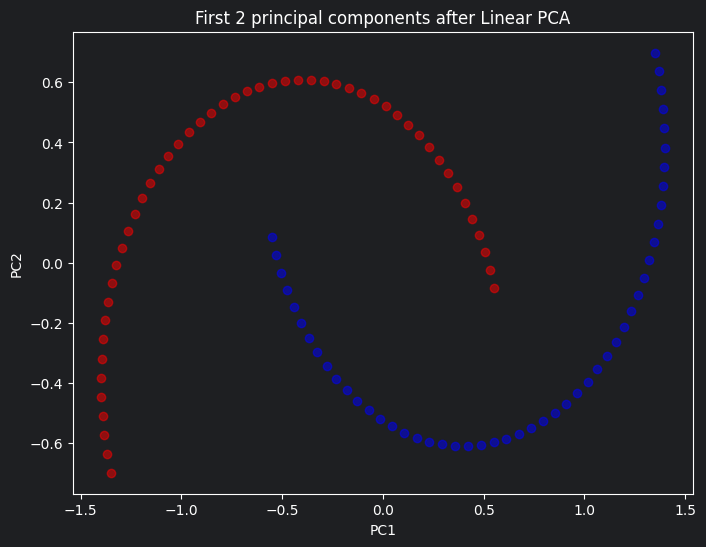

In [4]:
from sklearn.decomposition import PCA

scikit_pca = PCA(n_components=2)
X_spca = scikit_pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_spca[y==0, 0], X_spca[y==0, 1], color='red', alpha=0.5)
plt.scatter(X_spca[y==1, 0], X_spca[y==1, 1], color='blue', alpha=0.5)

plt.title('First 2 principal components after Linear PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

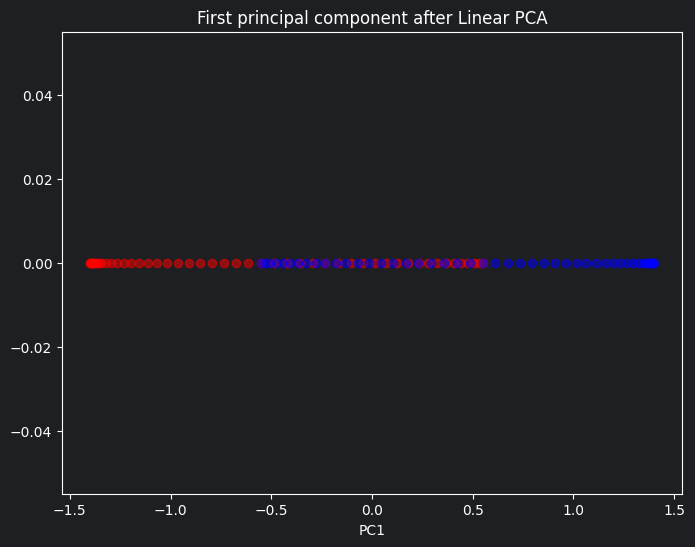

In [5]:
scikit_pca = PCA(n_components=1)
X_spca = scikit_pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_spca[y==0, 0], np.zeros((50,1)), color='red', alpha=0.5)
plt.scatter(X_spca[y==1, 0], np.zeros((50,1)), color='blue', alpha=0.5)

plt.title('First principal component after Linear PCA')
plt.xlabel('PC1')

plt.show()

In [6]:
X.shape

(100, 2)

In [7]:
import itertools
kernel_type = 'rbf'
param = 2

# implement KPCA with our defined RBF kernel and fit to moon dataset

# Step 1: Gram matrix
K = np.zeros((X.shape[0], X.shape[0]))
idx = range(X.shape[0])

for i, j in itertools.product(idx, idx):
    K[i,j] = kernelFunc(X[i], X[j], kernel_type, param)

# Step 2: Duble Centering
N = X.shape[0]
K_centered = K - (1/N)*np.dot(np.ones((N, N)), K) - (1/N)*np.dot(K, np.ones((N, N))) + (1/(N**2))*(np.ones((N, N)) @ K @ np.ones((N, N)))

# Step 3: Eigenvalues and eigenvectors
lam, alpha = LA.eigh(K_centered)

# Step 4: Sorting
indx = lam.argsort()[::-1]
lam = lam[indx]
alpha = alpha[:, indx]

# Step 5: 1st and 2nd PC
rbf_kpca = alpha[:, :2]

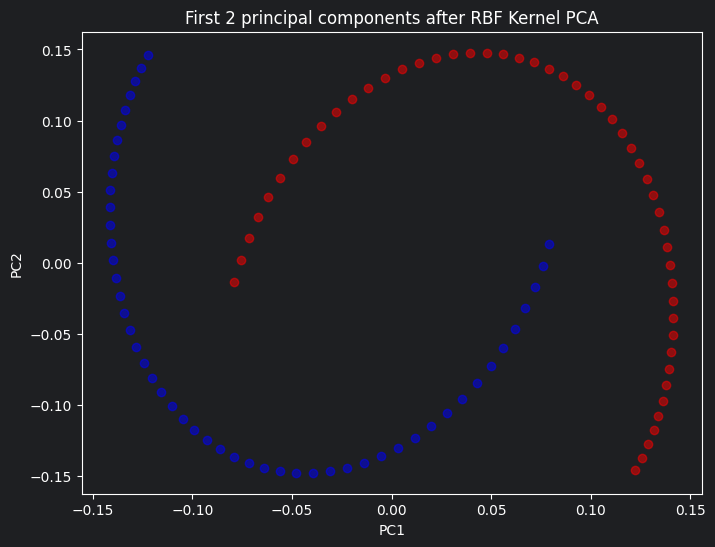

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(rbf_kpca[y==0, 0], rbf_kpca[y==0, 1], color='red', alpha=0.5)
plt.scatter(rbf_kpca[y==1, 0], rbf_kpca[y==1, 1], color='blue', alpha=0.5)

plt.title('First 2 principal components after RBF Kernel PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## Kernel SVM 

**Recall**: Suppport Vector Machines (SVM) separates data by finding an hyperplane which maximizes the margin between classes.

Kernel SVM use kernels to map data in a higher dimensional feature space, where the maximal margin hyperplane is learned. 
In this case we will use the bias and NOT use double centering in the formulation of the SVM.

To understand the Support Vector Machine (SVM) pipeline, you must view it as a mathematical journey from constrained optimization to efficient computation.

### Optimization Formulation

$$\min_{\boldsymbol{\alpha} \in \mathbb{R}^N, b} \frac{1}{2} \left\langle \sum_{i \in [N]} \alpha_i \boldsymbol{x}_i, \sum_{i \in [N]} \alpha_i \boldsymbol{x}_i \right\rangle + C \sum_{i \in [N]} \max(0, 1 - y_i(\sum_{j \in [N]} \alpha_j \boldsymbol{x}_j^\top \boldsymbol{x}_i + b))$$

$$\iff \min_{\boldsymbol{\alpha} \in \mathbb{R}^N, b} \frac{1}{2} \sum_{i \in [N], j \in [N]} \alpha_i \alpha_j \boldsymbol{x}_i^\top \boldsymbol{x}_j + C \sum_{i \in [N]} \max(0, 1 - y_i(\sum_{j \in [N]} \alpha_j \boldsymbol{x}_j^\top \boldsymbol{x}_i + b))$$

$$\iff \min_{\boldsymbol{\alpha} \in \mathbb{R}^N, b} \frac{1}{2} \boldsymbol{\alpha}^\top \boldsymbol{G} \boldsymbol{\alpha} + C \sum_{i \in [N]} \max(0, 1 - y_i(\boldsymbol{g}_i^\top \boldsymbol{\alpha} + b))$$

### Objective Function
We want to minimize:
$$f(\boldsymbol{\alpha}, b) = \frac{1}{2} \boldsymbol{\alpha}^\top \boldsymbol{G} \boldsymbol{\alpha} + C \sum_{i=1}^{N} \max(0, 1 - y_i(\sum_{j=1}^{N} \alpha_j K(\boldsymbol{x}_j, \boldsymbol{x}_i) + b))$$
Where $G_{ij} = K(\boldsymbol{x}_i, \boldsymbol{x}_j)$ is the Gram matrix.

### Subgradient Descent Update
Because of the `max(0, ...)` term, we use subgradients. Let $\mathcal{I}$ be the set of indices where the margin is violated ($y_i(\sum_{j} \alpha_j K(\boldsymbol{x}_j, \boldsymbol{x}_i) + b) < 1$).

**The updates at each step (with learning rate $\eta$):**

* **For $\boldsymbol{\alpha}$:**
    $$\boldsymbol{\alpha} \leftarrow \boldsymbol{\alpha} - \eta \left( \boldsymbol{G} \boldsymbol{\alpha} - C \sum_{i \in \mathcal{I}} y_i \boldsymbol{k}_i \right)$$
    *(where $\boldsymbol{k}_i$ is the $i$-th column of the Gram matrix $\boldsymbol{G}$)*

* **For $b$:**
    $$b \leftarrow b - \eta \left( - C \sum_{i \in \mathcal{I}} y_i \right)$$



### Practical Implementation
1.  **Precompute $\boldsymbol{G}$:** Calculate the $N \times N$ Gram matrix once using your chosen kernel $K(\boldsymbol{x}_i, \boldsymbol{x}_j)$.
2.  **Stochastic Update:** For faster convergence, pick a single index $i$ at each step. 
    * If $i \in \mathcal{I}$: Update using the gradient of both the quadratic and hinge terms.
    * If $i \notin \mathcal{I}$: Update only using the quadratic term ($\boldsymbol{G}\boldsymbol{\alpha}$).
3.  **Regularization:** The $\boldsymbol{G}\boldsymbol{\alpha}$ term acts as weight decay, keeping the model from overfitting.


### The Prediction Rule
$$f(\boldsymbol{x}_{test}) = \text{sgn} \left( \sum_{j=1}^{N} \alpha_j K(\boldsymbol{x}_j, \boldsymbol{x}_{test}) + b \right)$$

* **$K(\boldsymbol{x}_j, \boldsymbol{x}_{test})$**: The kernel similarity between your test point and each training point.
* **$\alpha_j$**: The weights learned during your gradient descent optimization.
* **$b$**: The bias learned during optimization.

In [9]:
# from svm lab
def hingeFunction(z):
    return np.maximum(1-z,0)


def hingesubgrad(z):
    g = np.zeros(z.shape)
    g[z < 1] = -1
    return g

def ReghingeLoss(X,labels,w, lam):
    d = np.shape(X)[0]
    L = np.mean(np.maximum(np.ones(d) - labels*(X@w), 0)) + lam * LA.norm(w,2) 
    return L

def svmGrad(X, labels, w, lam):
    g1 = hingesubgrad(np.diag(labels)@(X@w))
    g2 = np.diag(labels)@X
    return g1.dot(g2) + 2*lam*w

def svm_training(X, labels, lam, Iter, gamma):
    # get dimensions
    d = np.shape(X)[1]
    # initialise weight vector and set first column to a random vector
    W = np.zeros((d,Iter))
    W[:,0] = np.random.normal(0,0.01,d)
    # initialise loss vector
    L = np.zeros(Iter)

    for i in range(Iter-1):
        # update weights using subgradient descent algorithm
        W[:,i+1] = W[:,i] - gamma * svmGrad(X, labels, W[:,i], lam)

        # save loss
        L[i] = ReghingeLoss(X,labels,W[:,i],lam)

    return W, L

In [10]:
# implement helper functions for ksvm
def compute_gram_matrix(X1, X2, kernel_type, param):
    # Compute Gram matrix
    K = np.zeros((X1.shape[0], X2.shape[0]))
    idx1 = range(X1.shape[0])
    idx2 = range(X2.shape[0])

    for i, j in itertools.product(idx1, idx2):
        K[i,j] = kernelFunc(X1[i], X2[j], kernel_type, param)

    return K

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

kernel_type = 'rbf'
param = 15

# implement and test kernel SVM with our defined kernel and SVM
# converting zeros in -1
y_train[y_train==0] = -1
y_test[y_test==0] = -1

# Compute Gram matrix on training data
K_train = compute_gram_matrix(X_train, X_train, kernel_type, param)

# training using svm
W, L = svm_training(K_train, y_train, lam=0.01, Iter=1000, gamma=0.01)

# extracting final weights
alpha = W[:, -1]

# making the test data Gram matrix
K_test = compute_gram_matrix(X_test, X_train, kernel_type, param)

# making the predictions
y_pred = np.sign(K_test @ alpha)

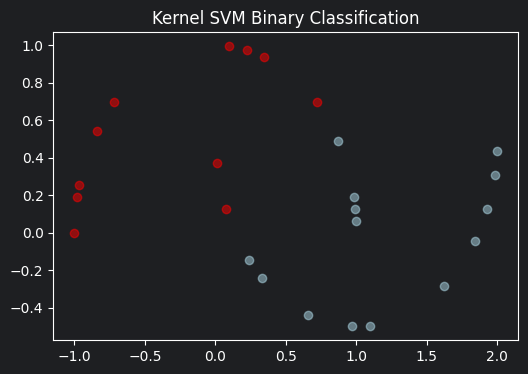

In [17]:
plt.figure(figsize=(6,4))

plt.scatter(X_test[y_pred==-1, 0], X_test[y_pred==-1, 1], color='red', alpha=0.5)
plt.scatter(X_test[y_pred==1, 0], X_test[y_pred==1, 1], color='lightblue', alpha=0.5)

plt.title('Kernel SVM Binary Classification')

plt.show()

**Sklearn Kernel SVM Function**

In [19]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc = SVC(kernel='rbf', gamma=15)
svc.fit(X_train, y_train)
y_pred_sk = svc.predict(X_test)
print('Accuracy with sklearn: ', accuracy_score(y_test, y_pred_sk))

Accuracy with sklearn:  1.0


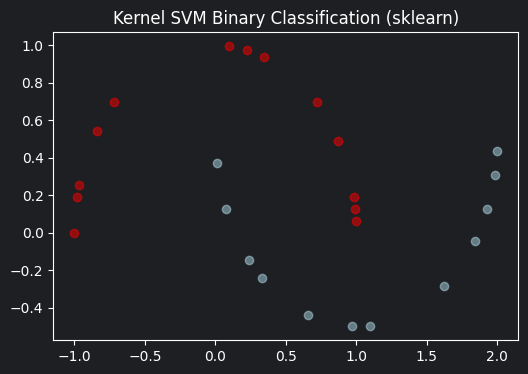

In [21]:
plt.figure(figsize=(6,4))

plt.scatter(X_test[y_pred_sk==-1, 0], X_test[y_pred_sk==-1, 1], color='red', alpha=0.5)
plt.scatter(X_test[y_pred_sk==1, 0], X_test[y_pred_sk==1, 1], color='lightblue', alpha=0.5)

plt.title('Kernel SVM Binary Classification (sklearn)')

plt.show()

## A more real life example
### The beloved MNIST dataset

The MNIST dataset (Modified National Institute of Standards and Technology) is a collection of 70,000 grayscale images of handwritten digits (0-9), each of size 28x28 pixels. It is widely used in machine learning and deep learning for image classification tasks. MNIST serves as a benchmark dataset for evaluating algorithms.

Let's see how our kernel methods work on the mnist dataset.
We will use sklearn methods.

Suggestion, choose a subset $\sim$ 10000 of those images, since otherwise you will need 200Gb of RAM :)

Tasks:

- Load MNIST dataset
- Apply classical PCA, plot the first two principal components, then visualize the eigenvectors
- Apply kernel PCA, plot the first two principal components (colour by class datapoints)
- Choose two classes (eg. 5 and 8) and build an SVM that can distinguish between them



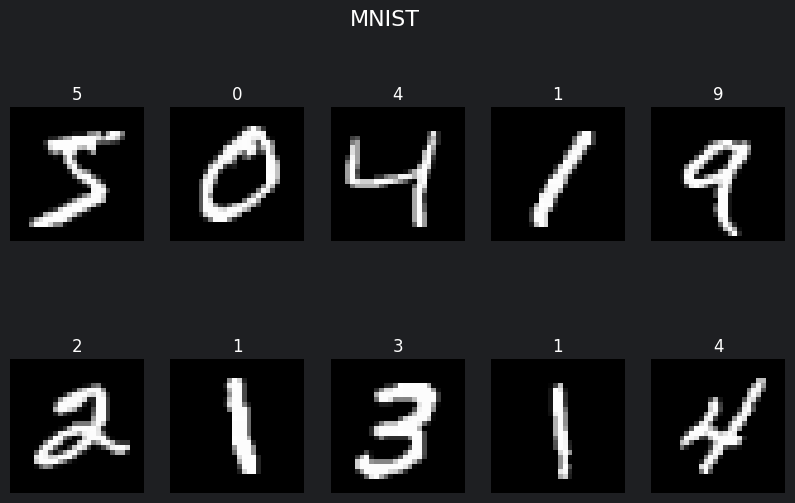

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Load MNIST from OpenML
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)


# Plot some sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 6))
fig.suptitle("MNIST", fontsize=16)

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i].reshape(28,28), cmap='gray')
    ax.set_title(f"{y[i]}")
    ax.axis("off")

plt.show()

In [23]:
# choosing 2 labels
X_58 = X[(y==5) | (y==8)]
y_58 = y[(y==5) | (y==8)]

# using train_test_split to extract a smaller dataset
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_58, y_58, train_size=500, test_size=100, random_state=42)

# converting the labels
y_train_bin[y_train_bin==5] = -1
y_train_bin[y_train_bin==8] = 1

y_test_bin[y_test_bin==5] = -1
y_test_bin[y_test_bin==8] = 1

In [25]:
# extracting 1st and 2nd PC
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_bin_pca = pca.fit_transform(X_train_bin)
X_test_bin_pca = pca.transform(X_test_bin)

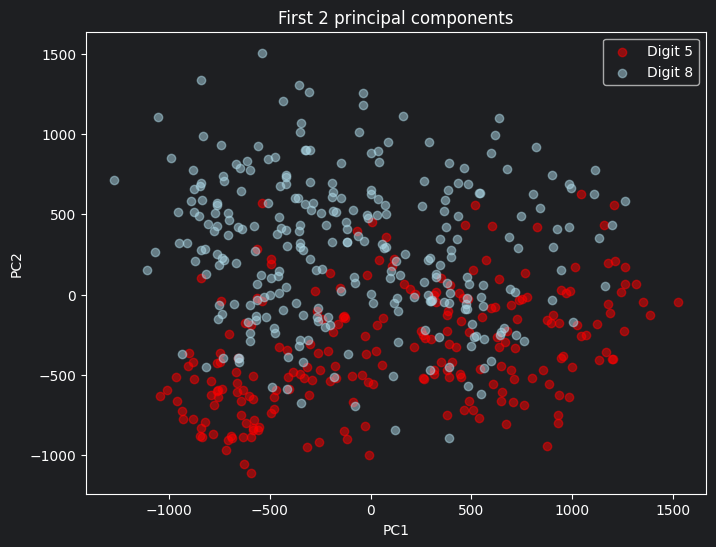

In [29]:
# plotting the PC's
plt.figure(figsize=(8,6))
plt.scatter(X_train_bin_pca[y_train_bin==-1, 0], X_train_bin_pca[y_train_bin==-1, 1], color='red', alpha=0.5, label='Digit 5')
plt.scatter(X_train_bin_pca[y_train_bin==1, 0], X_train_bin_pca[y_train_bin==1, 1], color='lightblue', alpha=0.5, label='Digit 8')

plt.title('First 2 principal components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

In [36]:
# using KernelPCA
kernel_type = 'rbf'
param = 1000000 # distance may be 10^6 or more so we need to increment the param
K_train_minist = compute_gram_matrix(X_train_bin, X_train_bin, kernel_type, param)

# Duble Centering
N = X_train_bin.shape[0]
K_train_centered = K_train_minist - (1/N)*np.dot(np.ones((N, N)), K_train_minist) - (1/N)*np.dot(K_train_minist, np.ones((N, N))) + (1/(N**2))*(np.ones((N, N)) @ K_train_minist @ np.ones((N, N)))

# Eigenvalues and eigenvectors
lam, alpha = LA.eigh(K_train_centered)

# Sorting
indx = lam.argsort()[::-1]
lam = lam[indx]
alpha = alpha[:, indx]

# 1st and 2nd PC and scaling
X_train_kpca = alpha[:, :2] * np.sqrt(lam[:2])

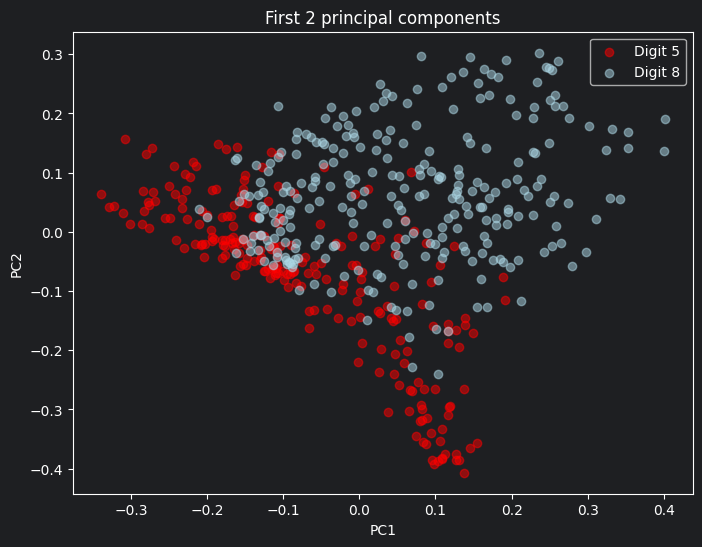

In [37]:
# plotting the PC's
plt.figure(figsize=(8,6))
plt.scatter(X_train_kpca[y_train_bin==-1, 0], X_train_kpca[y_train_bin==-1, 1], color='red', alpha=0.5, label='Digit 5')
plt.scatter(X_train_kpca[y_train_bin==1, 0], X_train_kpca[y_train_bin==1, 1], color='lightblue', alpha=0.5, label='Digit 8')

plt.title('First 2 principal components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

In [39]:
# training using svm
W, L = svm_training(K_train_minist, y_train_bin, lam=0.01, Iter=1000, gamma=0.01)

# extracting final weights
alpha = W[:, -1]

# making the test data Gram matrix
K_test_minist = compute_gram_matrix(X_test_bin, X_train_bin, kernel_type, param)

# making the predictions
y_pred_bin = np.sign(K_test_minist @ alpha)

print("Accuracy using KernelPCA: ", accuracy_score(y_pred_bin, y_test_bin))

Accuracy using KernelPCA:  0.97
